# 01 — Data Preparation

Download and prepare Yambda embeddings for SID experiments.
Set `DRY_RUN = True` for quick verification with synthetic data.

In [1]:
DRY_RUN = True

In [2]:
import sys
sys.path.insert(0, "..")

import numpy as np
import matplotlib.pyplot as plt
import yaml

from src.data.yambda_loader import load_yambda_embeddings, save_embeddings, load_embeddings

In [3]:
with open("../configs/default.yaml") as f:
    config = yaml.safe_load(f)

print(f"DRY_RUN = {DRY_RUN}")
print(f"Config data section: {config['data']}")

DRY_RUN = True
Config data section: {'source': 'yandex/yambda', 'embed_column': 'normalized_embed', 'n_items': 500000, 'seed': 42, 'output_path': 'data/embeddings.parquet'}


## Load Embeddings

In [4]:
item_ids, embeddings = load_yambda_embeddings(config, dry_run=DRY_RUN)
print(f"item_ids shape: {item_ids.shape}, dtype: {item_ids.dtype}")
print(f"embeddings shape: {embeddings.shape}, dtype: {embeddings.dtype}")

[dry-run] Generated 1000 random embeddings of dim 64
item_ids shape: (1000,), dtype: uint32
embeddings shape: (1000, 64), dtype: float32


## Inspect Embeddings

Norm stats: mean=1.0000, std=0.0000, min=1.0000, max=1.0000


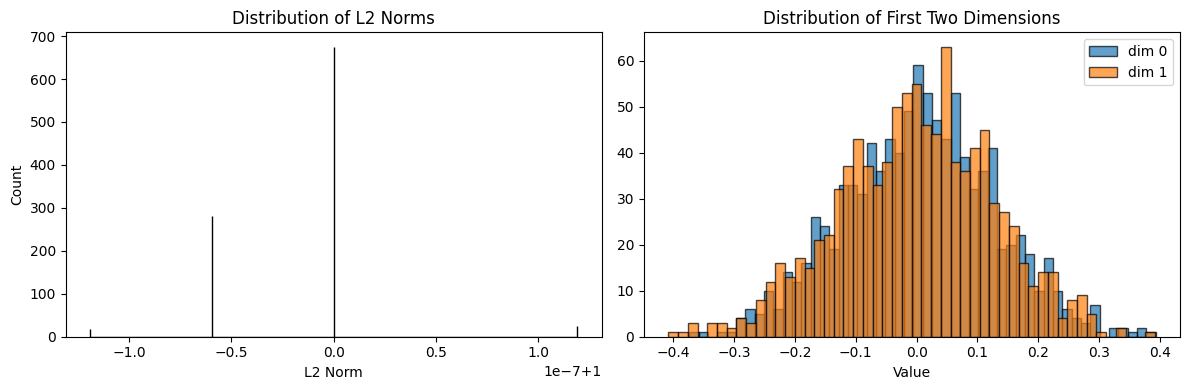

In [5]:
norms = np.linalg.norm(embeddings, axis=1)
print(f"Norm stats: mean={norms.mean():.4f}, std={norms.std():.4f}, "
      f"min={norms.min():.4f}, max={norms.max():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(norms, bins=50, edgecolor="black")
axes[0].set_title("Distribution of L2 Norms")
axes[0].set_xlabel("L2 Norm")
axes[0].set_ylabel("Count")

axes[1].hist(embeddings[:, 0], bins=50, edgecolor="black", alpha=0.7, label="dim 0")
axes[1].hist(embeddings[:, 1], bins=50, edgecolor="black", alpha=0.7, label="dim 1")
axes[1].set_title("Distribution of First Two Dimensions")
axes[1].set_xlabel("Value")
axes[1].legend()

plt.tight_layout()
plt.show()

## Save to Parquet

In [6]:
output_path = config["data"]["output_path"]
if DRY_RUN:
    output_path = output_path.replace(".parquet", "_dryrun.parquet")

save_embeddings(item_ids, embeddings, output_path)

Saved 1000 embeddings to data/embeddings_dryrun.parquet


In [7]:
# Verify round-trip
ids_loaded, emb_loaded = load_embeddings(output_path)
assert np.allclose(embeddings, emb_loaded, atol=1e-6)
assert np.array_equal(item_ids, ids_loaded)
print("Round-trip verification passed!")

Loaded 1000 embeddings of dim 64 from data/embeddings_dryrun.parquet
Round-trip verification passed!
